In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
diabetes = datasets.load_diabetes()
# print("Số chiều dữ liệu input: ", diabetes.data.shape)
# print("Kiểu dữ liệu input: ", type(diabetes.data))
# print("Số chiều dữ liệu target: ", diabetes.target.shape)
# print("Kiểu dữ liệu target: ", type(diabetes.target))
# print()
# print("5 mẫu dữ liệu đầu tiên:")
# print("input: ", diabetes.data[:5])
# print("target: ", diabetes.target[:5])
#print("data[5,1]", diabetes.data[4,1])
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [53]:
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, train_size = 361)
X_train = diabetes.data[:361] 
X_test = diabetes.data[362:]

y_train = diabetes.target[:361]
y_test = diabetes.target[362:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((361, 10), (80, 10), (361,), (80,))

In [62]:
regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)
y_pred = regr.predict(X_test)
print("w1 w2 w3 w4 w5 w6 w7 w8 w9 w10: ", regr.coef_)
print("w0 = ", regr.intercept_)
print("Accuracy: ", regr.score(X_test, y_test) * 100, "%")


w1 w2 w3 w4 w5 w6 w7 w8 w9 w10:  [-1.12982324e-02 -2.49782541e+02  5.18802202e+02  2.97220454e+02
 -6.39802236e+02  3.56330510e+02  2.77834385e+01  1.46962789e+02
  6.90474996e+02  1.05716702e+02]
w0 =  152.56041961097782
Accuracy:  56.31505527533233 %


In [ ]:
ridgeregr = linear_model.Ridge(alpha=0.1)
ridgeregr.fit(X_train, y_train)
y_pred_ridge = ridgeregr.predict(X_test)
print("w1 w2 w3 w4 w5 w6 w7 w8 w9 w10: ", ridgeregr.coef_)
print("w0 = ", ridgeregr.intercept_)    
print("Accuracy: ", ridgeregr.score(X_test, y_test) * 100, "%")

w1 w2 w3 w4 w5 w6 w7 w8 w9 w10:  [  10.51523842 -215.21946642  477.04576811  275.18547584  -64.84522547
  -82.84458659 -194.22465786  112.99561167  427.19001456  121.18397114]
w0 =  152.57401415344637
Accuracy:  54.933921342100355 %


In [75]:
# predict for test[1]
print("Real value for test[1]: ", y_test[0])

# predict with linear regression by library
print("Predict value for test[1] with linear regression: ", regr.predict(X_test[0].reshape(1, -1))[0])
# predict with linear regression by hand
w = regr.coef_
w0 = regr.intercept_
x = X_test[0]
y_pred_test1 = sum(w[i] * x[i] for i in range(len(w))) + w0
print("Predict value for test[1] with linear regression by hand: ", y_pred_test1)

#predict with ridge regression by library
print("Predict value for test[1] with ridge regression: ", ridgeregr.predict(X_test[0].reshape(1, -1))[0])
# predict with ridge regression by hand

w_ridge = ridgeregr.coef_
w0_ridge = ridgeregr.intercept_
y_pred_test1_ridge = sum(w_ridge[i] * x[i] for i in range(len(w_ridge))) + w0_ridge
print("Predict value for test[1] with ridge regression by hand: ", y_pred_test1_ridge)


Real value for test[1]:  321.0
Predict value for test[1] with linear regression:  234.35947872322683
Predict value for test[1] with linear regression by hand:  234.35947872322683
Predict value for test[1] with ridge regression:  226.73474004055703
Predict value for test[1] with ridge regression by hand:  226.73474004055703


In [77]:
y_pred = regr.predict(X_test)
pd.DataFrame(data = np.array([y_test,y_pred,abs(y_test - y_pred)]).T, columns = ["Real", "Predict", "Error"]    )

,Real,Predict,Error
0,321.0,234.359479,86.640521
1,58.0,163.999748,105.999748
2,262.0,163.520115,98.479885
3,206.0,167.189446,38.810554
4,233.0,254.806697,21.806697
...,...,...,...
75,178.0,191.710701,13.710701
76,104.0,104.626354,0.626354
77,132.0,122.693494,9.306506
78,220.0,210.454911,9.545089


In [78]:
math.sqrt(mean_squared_error(y_test, y_pred))


51.53921127468042

In [85]:
_lamda = [0,0.0001,0.001,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,10,20,100]

for l in _lamda:
    ridgeregr = linear_model.Ridge(alpha=l)
    ridgeregr.fit(X_train, y_train)
    y_pred_ridge = ridgeregr.predict(X_test)
    print("Lambda = ",l, " - RMSE: ", math.sqrt(mean_squared_error(y_test, y_pred_ridge)), " - Accuracy: ", ridgeregr.score(X_test, y_test) * 100, "%")

Lambda =  0  - RMSE:  51.53921127468042  - Accuracy:  56.31505527533233 %
Lambda =  0.0001  - RMSE:  51.546352409239816  - Accuracy:  56.30294869966084 %
Lambda =  0.001  - RMSE:  51.60467342930754  - Accuracy:  56.20401256994383 %
Lambda =  0.1  - RMSE:  52.347597926523825  - Accuracy:  54.933921342100355 %
Lambda =  0.2  - RMSE:  52.828576682164666  - Accuracy:  54.10196694830407 %
Lambda =  0.3  - RMSE:  53.39826239553692  - Accuracy:  53.10673148852029 %
Lambda =  0.4  - RMSE:  54.003390768876365  - Accuracy:  52.03788647058947 %
Lambda =  0.5  - RMSE:  54.613321511474574  - Accuracy:  50.94837092524151 %
Lambda =  0.6  - RMSE:  55.21181910547772  - Accuracy:  49.86738402461602 %
Lambda =  0.7  - RMSE:  55.790662926851915  - Accuracy:  48.810687336888506 %
Lambda =  0.8  - RMSE:  56.346065679377475  - Accuracy:  47.78642273427114 %
Lambda =  0.9  - RMSE:  56.8766962413592  - Accuracy:  46.79836514369521 %
Lambda =  1  - RMSE:  57.382574887617025  - Accuracy:  45.847773370542114 %
L

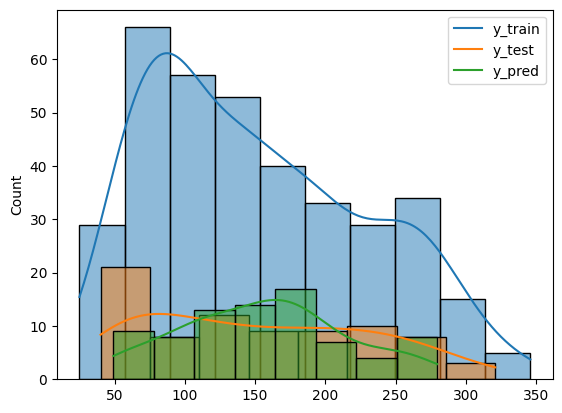

,values
count,80.00000
mean,152.38750
std,78.46994
min,40.00000
25%,72.00000
50%,140.00000
75%,217.50000
max,321.00000


In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(y_train, kde=True)
sns.histplot(y_test, kde=True)
sns.histplot(y_pred, kde=True)
# legend 
plt.legend(["y_train", "y_test", "y_pred"])
plt.show()
pd.DataFrame(data=y_test, columns=["values"]).describe()



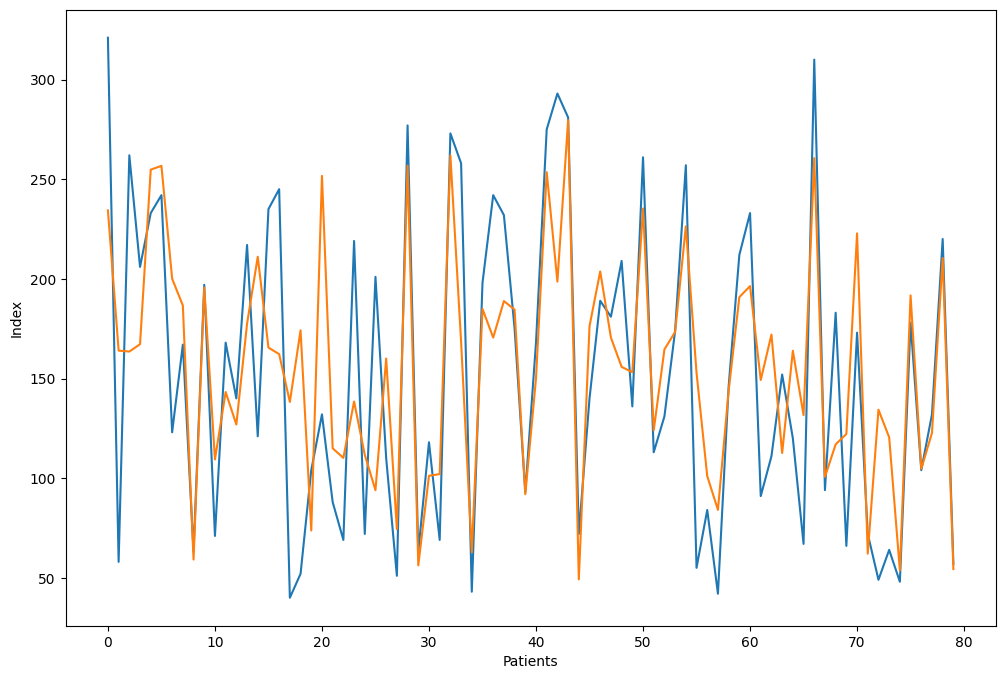

In [100]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(y_test)
plt.plot(y_pred)
plt.xlabel('Patients')
plt.ylabel('Index')
plt.show()